In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

pd.options.display.max_columns = None

In [32]:
train_base = pd.read_csv("./sign/sign_mnist_train.csv")
test_base = pd.read_csv("./sign/sign_mnist_test.csv")

In [33]:
# trainとtestでcsvが用意されていたのでそれを目的変数yと説明変数Xに分割
y_train = train_base['label'].values
X_train = train_base.drop(columns='label').values.reshape(len(train_base), 28,28,1)
y_test = test_base['label'].values
X_test = test_base.drop(columns='label').values.reshape(len(test_base), 28,28,1)

# 検証データを用意(割合はtestデータと同じ)
size = len(test_base) / (len(train_base) + len(test_base))
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=size, random_state=0)

In [34]:
# One-hotエンコード
y_train = tf.one_hot(y_train, 25)
y_valid = tf.one_hot(y_valid, 25)
y_test = tf.one_hot(y_test, 25)

# データの確認
print(f"y_train={y_train.shape}, y_valid={y_valid.shape}, y_test={y_test.shape}")
print(f"X_train={X_train.shape}, X_valid={X_valid.shape}, X_test={X_test.shape}")

y_train=(21768, 25), y_valid=(5687, 25), y_test=(7172, 25)
X_train=(21768, 28, 28, 1), X_valid=(5687, 28, 28, 1), X_test=(7172, 28, 28, 1)


In [35]:
inputs = tf.keras.Input(shape=(28, 28, 1))

# 96x96x3にリサイズ & RGB化
x = tf.keras.layers.Resizing(224, 224)(inputs)
x = tf.keras.layers.Lambda(lambda t: tf.image.grayscale_to_rgb(t))(x) 

# MobileNetV3 の前処理（[-1, 1]へスケーリング）
x = tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input)(x)

# 事前学習済みベース（トップなし、グローバルプーリング）
base = tf.keras.applications.MobileNetV3Small(
    include_top=False,
    weights='imagenet',
    input_tensor=x,
    pooling='avg'
)
# 転移学習の前半はベースを凍結
base.trainable = False

# 追加の分類ヘッド
h = tf.keras.layers.Dropout(0.3)(base.output)
h = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(h)
h = tf.keras.layers.Dropout(0.4)(h)
outputs = tf.keras.layers.Dense(25, activation='softmax')(h)

model = tf.keras.models.Model(inputs=inputs, outputs=outputs)

# モデルの構築
model.compile(optimizer = "adam", loss="categorical_crossentropy", metrics=['accuracy'])

In [36]:
%%time
# 学習の実施
log = model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=True,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=50, verbose=1)],
                validation_data=(X_valid, y_valid))


Epoch 1/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 66s 93ms/step - accuracy: 0.5732 - loss: 1.3972 - val_accuracy: 0.9458 - val_loss: 0.3178
Epoch 2/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 67s 98ms/step - accuracy: 0.8384 - loss: 0.5245 - val_accuracy: 0.9833 - val_loss: 0.1487
Epoch 3/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 72s 105ms/step - accuracy: 0.8889 - loss: 0.3732 - val_accuracy: 0.9921 - val_loss: 0.1035
Epoch 4/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 73s 107ms/step - accuracy: 0.9126 - loss: 0.3074 - val_accuracy: 0.9979 - val_loss: 0.0851
Epoch 5/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 77s 113ms/step - accuracy: 0.9285 - loss: 0.2651 - val_accuracy: 0.9975 - val_loss: 0.0760
Epoch 6/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 79s 115ms/step - accuracy: 0.9346 - loss: 0.2491 - val_accuracy: 0.9995 - val_loss: 0.0731
Epoch 7/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 82s 120ms/step - accuracy: 0.9420 - loss: 0.2305 - val_accuracy: 1.0000 - val_loss: 0.0694
Epoch 8/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 89s 131ms/step - accuracy: 0.9442 - loss: 0.2

Text(0, 0.5, 'crossentropy')

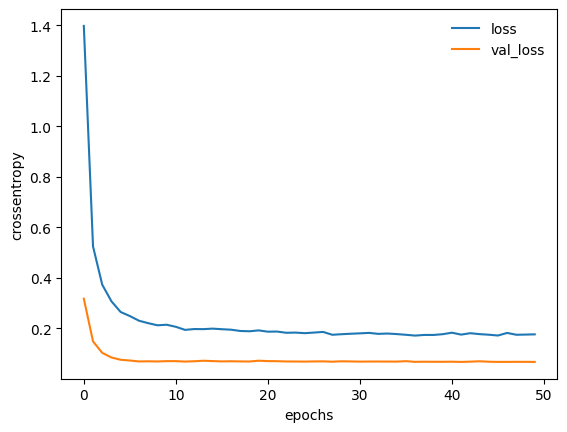

In [37]:
plt.plot(log.history['loss'], label='loss')
plt.plot(log.history['val_loss'], label='val_loss')
plt.legend(frameon=False)
plt.xlabel("epochs")
plt.ylabel("crossentropy")

In [38]:
y_pred = np.argmax(model.predict(X_test), axis=1)
y_test_ = np.argmax(y_test, axis=1)
print(classification_report(y_test_, y_pred))

225/225 ━━━━━━━━━━━━━━━━━━━━ 26s 110ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       1.00      1.00      1.00       432
           2       1.00      1.00      1.00       310
           3       1.00      1.00      1.00       245
           4       1.00      1.00      1.00       498
           5       1.00      1.00      1.00       247
           6       0.98      1.00      0.99       348
           7       1.00      0.99      0.99       436
           8       1.00      1.00      1.00       288
          10       1.00      1.00      1.00       331
          11       1.00      1.00      1.00       209
          12       1.00      1.00      1.00       394
          13       1.00      1.00      1.00       291
          14       1.00      1.00      1.00       246
          15       1.00      1.00      1.00       347
          16       1.00      1.00      1.00       164
          17       1.00      0.97    